# Bend Topology Optimization -- Meep Adjoint

The fourth "LEGO block" in the toolkit, and the first that does not pick a design
from a small parametric family (a radius, a gap) -- instead, a freeform pixel
density inside a fixed design-region footprint is optimized directly against an
adjoint-computed gradient.

**Do not use "Run All."** The optimization in Section 5 takes real wall-clock time;
run it once, inspect the result, and only re-run from Section 2 if you actually want
a different design.

## 1. Physical objective

`02_bent_waveguide.ipynb` answered "how much radius does a 90-degree bend need?" for a
*parametric* family of designs -- a single quarter-circle arc, tunable only by its
radius. Allowing the material distribution inside the corner to be an arbitrary
freeform shape gives the optimizer far more room to redirect the guided mode with
less reflection and less radiation into the cladding, within the same footprint.

**Method:** `meep.adjoint` computes the gradient of a transmission objective with
respect to every pixel of a design-region density grid, using one adjoint FDTD run per
iteration (instead of one run per pixel) -- this is what makes optimizing hundreds of
parameters tractable. `nlopt`'s MMA algorithm then takes gradient-ascent steps on that
objective. The pixel grid is filtered (a minimum feature size) and projected (pushed
toward pure 0/1 density) before every evaluation, so the result approaches a
manufacturable binary structure rather than a diffuse gray blob.

Same two-port S-parameter philosophy as every other component: **the optimizer's own
objective is not what gets trusted or saved.** Section 8 re-measures the *final*,
frozen design with the toolkit's standard two-independent-direction eigenmode-
decomposition method (the same one `bend.py` uses) before anything is validated or
cached.

**Governing relations.** The objective is the mode-transmission power
$F = |S_{21}|^2$ at the design wavelength. A direct finite-difference gradient
($\partial F/\partial ho_i$ for each of $N$ pixels, one extra simulation per pixel)
does not scale; the adjoint method instead gets the FULL gradient from just two FDTD
runs per iteration -- the forward run above and one adjoint run with sources placed
at the objective's own output port -- via
$$rac{\partial F}{\partial ho_i} \propto \mathrm{Re}\!\left[\int_{\Omega_i} \mathbf{E}_\mathrm{fwd}(\mathbf{r})\cdot\mathbf{E}_\mathrm{adj}(\mathbf{r})\,rac{\partial arepsilon}{\partial ho_i}\, d\mathbf{r}ight],$$
a volume overlap integral of the forward and adjoint fields over each pixel's own
region $\Omega_i$. Before every evaluation, the raw density $ho$ is smoothed by a
conic filter (`mpa.conic_filter`, enforcing `filter_radius_um` as an approximate
minimum feature size) and pushed toward binary values by a tanh projection
(`mpa.tanh_projection`),
$$	ildeho = rac{	anh(eta\eta) + 	anh(eta(ho_\mathrm{filt}-\eta))}{	anh(eta\eta) + 	anh(eta(1-\eta))},$$
with $eta$ raised across `beta_schedule`'s successive stages (Section 5) so early
iterations explore gray designs freely and late iterations converge toward a
manufacturable 0/1 structure.

In [1]:
import inspect

import numpy as np
import matplotlib.pyplot as plt

from pic_toolkit.meep_sim import bend_topopt
from pic_toolkit import checks, viz, sparams, design_points, style

style.apply_style()
%matplotlib inline

## 2. User-adjustable parameters

Kept in one place (`DEFAULT_PARAMS`), separate from the simulation/optimization
mechanics in `meep_sim/bend_topopt.py` -- same convention as every other component.

In [2]:
params = dict(bend_topopt.DEFAULT_PARAMS)  # a working copy -- edit this dict, not the module default
params


{'wg_width_um': 0.5,
 'core_index': 2.7,
 'clad_index': 1.44,
 'cell_x_um': 9.8,
 'cell_y_um': 8.8,
 'dpml_um': 1.0,
 'design_region_center': (1.0, -0.5),
 'design_region_x_um': 4.5,
 'design_region_y_um': 4.5,
 'init_bend_radius_um': 1.0,
 'design_grid_n': 31,
 'resolution': 20,
 'wavelength_um': 1.35,
 'source_fwidth_frac': 0.2,
 'source_inset_um': 0.3,
 'port_gap_um': 0.7,
 'mode_size_um': 2.0,
 'filter_radius_um': 0.2,
 'eta': 0.5,
 'beta_schedule': [4.0, 8.0, 16.0, 32.0],
 'iters_per_stage': 20,
 'adjoint_minimum_run_time': 50,
 'init_density': 0.5,
 'init_step': 0.02,
 'wl_min_um': 1.3,
 'wl_max_um': 1.4,
 'n_freq': 21}

What each parameter means physically (see `docs/simulation_settings_record.md` for
the experiments behind the non-obvious choices):

- **`cell_x_um` / `cell_y_um` / `dpml_um`** -- domain size and PML thickness, grown
  to keep the same PML clearance around the design region below.
- **`design_region_center` / `design_region_x_um` / `design_region_y_um`** -- the
  freeform region, positioned at the bottom-right corner where the input (horizontal)
  and output (vertical) arms meet. Sized at 4.5x4.5um -- big enough to contain a full,
  unclipped R=1um Euler (clothoid) warm-start bend (see `init_bend_radius_um` below).
- **`init_bend_radius_um`** -- the minimum radius of the Euler-spiral curve
  `build_euler_initial_density()` rasterizes as the optimizer's STARTING density,
  instead of a uniform gray field (every other component's convention). A blank,
  uniform-gray start did not converge well here; warming the optimizer up from an
  already-good bend shape it only needs to REFINE did -- see Section 3.
- **`design_grid_n`** -- the design region is a **31x31** grid (961 independent density
  variables), grid pitch 0.15um.
- **`resolution`** -- FDTD pixels/um. 20, same as `bend.py`'s baseline.
- **`wavelength_um`** -- the *single* wavelength the adjoint objective targets (unlike
  every other component's broadband sweep -- optimizing a single frequency per
  iteration is what keeps each adjoint run cheap). The honest validation in Section 8
  still measures the full O-band (`wl_min_um`-`wl_max_um`), exactly like every other
  component.
- **`filter_radius_um`** -- conic-filter radius, an approximate minimum feature size:
  larger values push the optimizer toward smoother, more fabricable shapes at some
  cost in raw performance.
- **`beta_schedule` / `eta`** -- tanh-projection sharpness (run in increasing STAGES --
  beta continuation, see Section 5) and midpoint, pushing the filtered density toward
  pure 0 (cladding) or 1 (silicon) rather than intermediate gray values. Starting soft
  and progressively sharpening is what stabilizes convergence.
- **`adjoint_minimum_run_time`** -- a floor on every forward/adjoint FDTD run's length,
  so an iteration can't stop (and report a noisy objective/gradient) before the fields
  have had enough time to settle.
- **`init_density`** -- unused when a warm start (`init_weights=`) is passed to
  `run_adjoint_optimization()`, as Section 5 does -- kept only as the fallback for a
  uniform-gray start.
- **`iters_per_stage`** -- NLopt MMA evaluations per `beta_schedule` stage. This is the
  expensive knob: each iteration is one forward + one adjoint FDTD run. There is
  deliberately no parameter sweep in this notebook (see Section 6) -- the per-iteration
  objective history *is* this notebook's swept axis.
- **`wl_min_um` / `wl_max_um` / `n_freq`** -- the *validation* band (Section 8), same
  O-band convention as every other component.

## 3. Geometry construction and permittivity map (initial guess)

`build_geometry(params, weights)` builds oversized straight input/output arms that
extend *through* the design region, plus the design region itself as an `mp.MaterialGrid`
listed last in the geometry -- Meep gives later objects precedence at overlapping
points, so the MaterialGrid's density overrides the arms wherever they overlap it, and
the arms are the only material everywhere else. Here is the actual function used:

In [3]:
# Print the actual geometry-building function's source -- the design region
# (a MaterialGrid) is listed LAST so it overrides the straight input/output
# arms wherever the two overlap (see its docstring).
print(inspect.getsource(bend_topopt.build_geometry))


def build_geometry(params: dict, weights=None) -> list:
    """Straight input (horizontal) and output (vertical) arms, oversized so
    they extend THROUGH the bottom-right design region -- the design region
    is listed last, so Meep's later-object precedence lets its MaterialGrid
    density override the arms wherever they overlap it. Everywhere else, the
    arms are the only material -- ordinary single-material silicon wire."""
    core = mp.Medium(index=params["core_index"])
    w = params["wg_width_um"]
    Sx, Sy = params["cell_x_um"], params["cell_y_um"]
    x0, y0 = params["design_region_center"]
    Lx, Ly = params["design_region_x_um"], params["design_region_y_um"]

    in_x1, in_x2 = -Sx / 2, x0 + Lx / 2
    in_wg = mp.Block(
        center=mp.Vector3((in_x1 + in_x2) / 2, y0),
        size=mp.Vector3(in_x2 - in_x1, w),
        material=core,
    )
    out_y1, out_y2 = y0 - Ly / 2, Sy / 2
    out_wg = mp.Block(
        center=mp.Vector3(x0, (out_y1 + out_y2) / 2),
        s

**Warm start, not a blank guess:** unlike every other component's `weights=None`
uniform-gray starting point, the design region below is initialized from a real,
already-good bend shape -- a symmetric 90-degree Euler (clothoid) curve of true
minimum radius `init_bend_radius_um` (1.0um), rasterized onto the design grid by
`build_euler_initial_density()` (see `docs/simulation_settings_record.md` for why a
blank start failed here). Since the adjoint optimizer only *refines* a design via
gradient ascent, starting from a shape that already bends light reasonably well means
the final result only has to get as good as (or a bit better than) that reference
shape -- not discover a working bend from nothing in 80 evaluations.

def build_euler_initial_density(params: dict, radius_um: float) -> np.ndarray:
    """Rasterize a symmetric 90-degree Euler (clothoid) bend of true minimum
    radius `radius_um` onto the design region's (design_grid_n x
    design_grid_n) density grid -- a warm-start initial guess for
    run_adjoint_optimization(init_weights=...), instead of a uniform gray
    density (see design_region_x_um's comment in DEFAULT_PARAMS for why).

    The centerline is built by numerically integrating the standard
    symmetric Euler-spiral curvature profile (ramps linearly 0 -> 1/
    radius_um over the first half-arc-length, then back to 0 over the
    second half, sweeping a total 90-degree turn -- Fresnel integrals have
    no elementary closed form, hence numeric). It is placed so it starts
    EXACTLY on the input arm's line (y=y0, heading +x) and ends EXACTLY on
    the output arm's line (x=x0, heading +y) -- both by construction, not
    approximation. Straight connector segments fill the desi

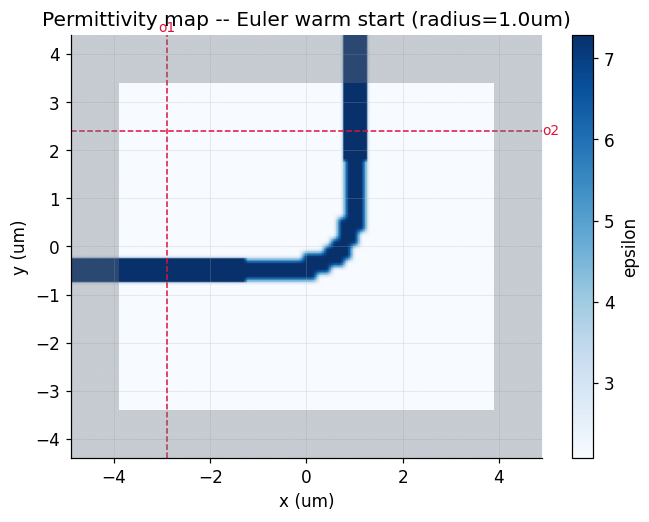

In [4]:
# Rasterize a real, already-good Euler-bend shape onto the design grid as the
# optimizer's STARTING density (warm start), instead of a blank uniform-gray
# field -- see the markdown above and docs/simulation_settings_record.md for
# why a blank start didn't work here.
print(inspect.getsource(bend_topopt.build_euler_initial_density))

initial_density = bend_topopt.build_euler_initial_density(params, params["init_bend_radius_um"])
perm_map = bend_topopt.get_permittivity_map(params, weights=initial_density)

dom = bend_topopt._domain(params)
ports = [
    (dom["port1_x"], dom["y0"], "o1", "v"),
    (dom["x0"], dom["port2_y"], "o2", "h"),
]

fig, ax = plt.subplots(figsize=(7, 5))
viz.plot_permittivity(perm_map.eps, perm_map.extent_um, ax=ax, ports=ports, pml_um=params["dpml_um"])
ax.set_title(f"Permittivity map -- Euler warm start (radius={params['init_bend_radius_um']}um)")
plt.show()


> **STOP: Inspect the permittivity map before running any FDTD.**
>
> Check: does the input waveguide arrive from the left at `y=-0.5`, does the output
> waveguide leave upward at `x=1.0`, and does a smooth curved bend (NOT a uniform gray
> square -- see the warm-start note above) connect the two with no gaps? Is there
> visible clearance between the structure and the domain edges? If not, fix `params`
> above and re-run from Section 3 before continuing.

## 4. Adjoint optimization setup: objective and monitors

`build_optimization_problem(params)` assembles the `mpa.OptimizationProblem`: the same
input/output arms as `build_geometry()`, the `MaterialGrid` design region, and
`mpa.EigenmodeCoefficient` monitors at the *same* two reference planes
(`o1`/`o2`) that Section 8's honest validation uses later -- so what the optimizer
chases and what actually gets measured are defined at identical locations, not just
"the same device" loosely.

**Objective:** `J = |c_out / c_in|^2` -- normalized by the reference input
coefficient, so it approximates true transmission at the design wavelength, rather
than the source notebook's unnormalized `|c_top|^2` (which depends on absolute source
power, not just the device). This does not replace Section 8's independently-measured
`|S21|^2` -- it is the cheap, single-direction, single-frequency proxy the optimizer
actually climbs every iteration.

In [5]:
# Print the actual optimization-problem builder -- note the objective is
# |c_out/c_in|^2 (normalized transmission), not a raw, unnormalized power.
print(inspect.getsource(bend_topopt.build_optimization_problem))


def build_optimization_problem(params: dict):
    """Assemble the mpa.OptimizationProblem: the same input/output arms as
    build_geometry(), a MaterialGrid design region, and EigenmodeCoefficient
    monitors at the SAME o1/o2 reference planes simulate_baseline() uses --
    so the optimization objective and the final honest validation measure at
    identical locations. Objective is `|c_out / c_in|^2`, normalized by the
    reference input coefficient (unlike the source notebook's raw
    `|c_top|^2`) so it approximates true transmission, not an arbitrary
    unnormalized power.

    Returns (opt, design_variables, design_region) -- design_variables is
    what `nlopt`'s objective callback updates every iteration.
    """
    dom = _domain(params)
    fcen = 1.0 / params["wavelength_um"]
    df = params["source_fwidth_frac"] * fcen
    mode_size = params["mode_size_um"]
    core = mp.Medium(index=params["core_index"])
    w = params["wg_width_um"]
    Sx, Sy = params["cell_x_um"], p

**Filtering and projection:** applied to the raw pixel grid before every
objective evaluation -- a conic filter (`filter_radius_um`, approximate minimum
feature size) followed by a tanh projection (`beta`/`eta`, pushes density toward pure
0/1; `beta` is whichever `beta_schedule` stage Section 5 is currently running).
`autograd.tensor_jacobian_product` chain-rules the adjoint gradient back through this
mapping, so the optimizer's gradient step is with respect to the *raw* variables, not
the filtered/projected ones directly.

In [6]:
# Print the filter+projection step applied to the raw pixel grid before every
# objective evaluation (conic filter for minimum feature size, tanh
# projection for binarization pressure).
print(inspect.getsource(bend_topopt._mapping))


def _mapping(x, params: dict):
    """Conic filter (minimum feature size) + tanh projection (binarization
    pressure), applied before every objective evaluation -- an addition
    over the source notebook, which optimized the raw pixel grid directly."""
    n = params["design_grid_n"]
    Lx, Ly = params["design_region_x_um"], params["design_region_y_um"]
    # meep.adjoint.mesh_grid derives its own Nx = round(Lx*resolution)+1 --
    # (n-1)/Lx is what makes that come back out to n, matching design_grid_n.
    design_region_resolution = (n - 1) / Lx
    filtered = mpa.conic_filter(
        x.reshape(n, n), params["filter_radius_um"], Lx, Ly, design_region_resolution
    )
    projected = mpa.tanh_projection(filtered, params["beta"], params["eta"])
    return projected.flatten()



## 5. Run the adjoint optimization

One forward + one adjoint FDTD run per iteration; progress is printed live
(`[i/N  P%]  beta=...  J=...`), same `[i/N P%]` style as `sweep.grid_sweep`'s progress
reporting elsewhere in the toolkit. Runs as `len(beta_schedule)` successive **beta
continuation** stages -- each stage re-optimizes from the previous stage's result at a
higher projection sharpness (`params["beta_schedule"]`), rather than one fixed beta for
the whole budget. This is deliberately slower than a single-beta run, in exchange for
more stable convergence: a fixed high beta from the start makes the earliest
iterations, where the density is still far from binary, erratic -- there is very little
usable gradient signal in a landscape that's already being projected hard toward 0/1.

In [7]:
# Run the full adjoint optimization loop: one forward + one adjoint FDTD run
# per iteration, warm-started from the Euler-bend density built above, and
# stepped through beta_schedule's increasing binarization-sharpness stages.
opt_result = bend_topopt.run_adjoint_optimization(params, init_weights=initial_density)
print(f"\n{len(opt_result.evaluation_history)} iterations across "
      f"{len(params['beta_schedule'])} beta stages, "
      f"J: {opt_result.evaluation_history[0]:.4f} -> {opt_result.evaluation_history[-1]:.4f}")
print(f"final design fill fraction: {opt_result.final_weights_binarized.mean():.3f}")


[1/80  1%]  beta=4  J=0.832388


[2/80  2%]  beta=4  J=0.832389


[3/80  3%]  beta=4  J=0.832405


[4/80  5%]  beta=4  J=0.832622


[5/80  6%]  beta=4  J=0.834660


...

[77/80  96%]  beta=32  J=0.984445


[78/80  97%]  beta=32  J=0.975947


[79/80  98%]  beta=32  J=0.984653


[80/80  100%]  beta=32  J=0.984710



80 iterations across 4 beta stages, J: 0.8324 -> 0.9847
final design fill fraction: 0.098


## 6. Convergence -- this notebook's sweep-equivalent

Every other component notebook sweeps a small parameter grid (a radius, a gap) and
plots a result per grid point. A topology-optimization run has no such grid -- the
natural swept axis is **iteration**, and the objective at each iteration is already
computed for free as a byproduct of the optimization loop above.

**Why the objective dips at each dashed line:** those lines mark beta-stage
boundaries (iterations 20, 40, 60). At each boundary, `beta` jumps to the next,
sharper value in `beta_schedule` while the raw optimizer variable carries over
unchanged from the previous stage -- and since the tanh projection is much sharper
at higher `beta`, that same raw variable now maps to a visibly more binarized
density. The geometry -- and so the objective -- changes discontinuously right at
the jump, then the optimizer recovers over the following iterations. This is
expected, benign behavior, not a bug: it's the price of the beta-continuation
schedule that keeps the *earlier* iterations from being erratic (see Section 2).
It is not something this notebook tries to smooth away -- the trusted result is
Section 8's independently-measured S-parameters, not this per-iteration curve.

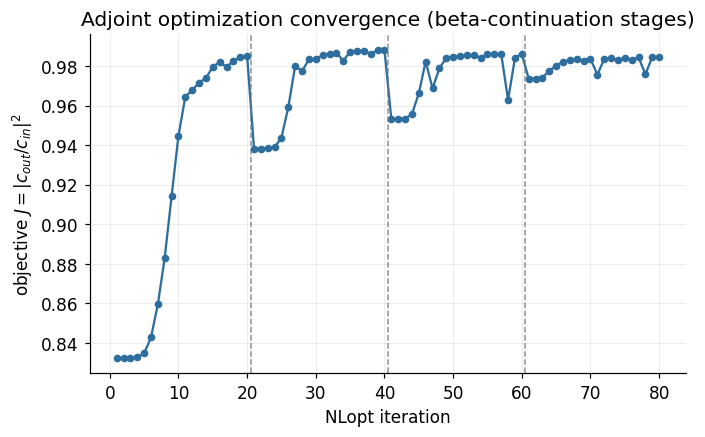

In [8]:
iters_per_stage = params["iters_per_stage"]
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(np.arange(1, len(opt_result.evaluation_history) + 1), opt_result.evaluation_history,
        "-o", ms=4, color=style.COLOR_STEEL)
for stage_end in range(iters_per_stage, len(opt_result.evaluation_history), iters_per_stage):
    ax.axvline(stage_end + 0.5, color=style.COLOR_REFERENCE, linestyle="--", linewidth=1, alpha=0.8)
ax.set_xlabel("NLopt iteration")
ax.set_ylabel(r"objective $J = |c_{out}/c_{in}|^2$")
ax.set_title("Adjoint optimization convergence (beta-continuation stages)")
plt.show()

**Caveat:** `J` is a single-direction, single-frequency proxy computed *during* the
FDTD run, before DFT fields have fully converged -- it is expected to trend upward
with iteration, not to equal the independently-measured `|S21|^2` from Section 8
exactly. Section 8, not this plot, is what gets saved and trusted.

## 7. Electromagnetic field visualization -- final design

The final binarized design (thresholded at 0.5, `opt_result.final_weights_binarized`)
is now run through the toolkit-standard two-port extraction --
`simulate_baseline(params, weights=...)`, structurally the same method `bend.py` uses
(two independent directions, full-band eigenmode decomposition). This single call
produces both this section's permittivity/field snapshot and Section 8's
S-parameters. The permittivity map is shown in green to mark it as the optimized
final design, distinct from Section 3's blue initial-guess map.

dominant field: Hz


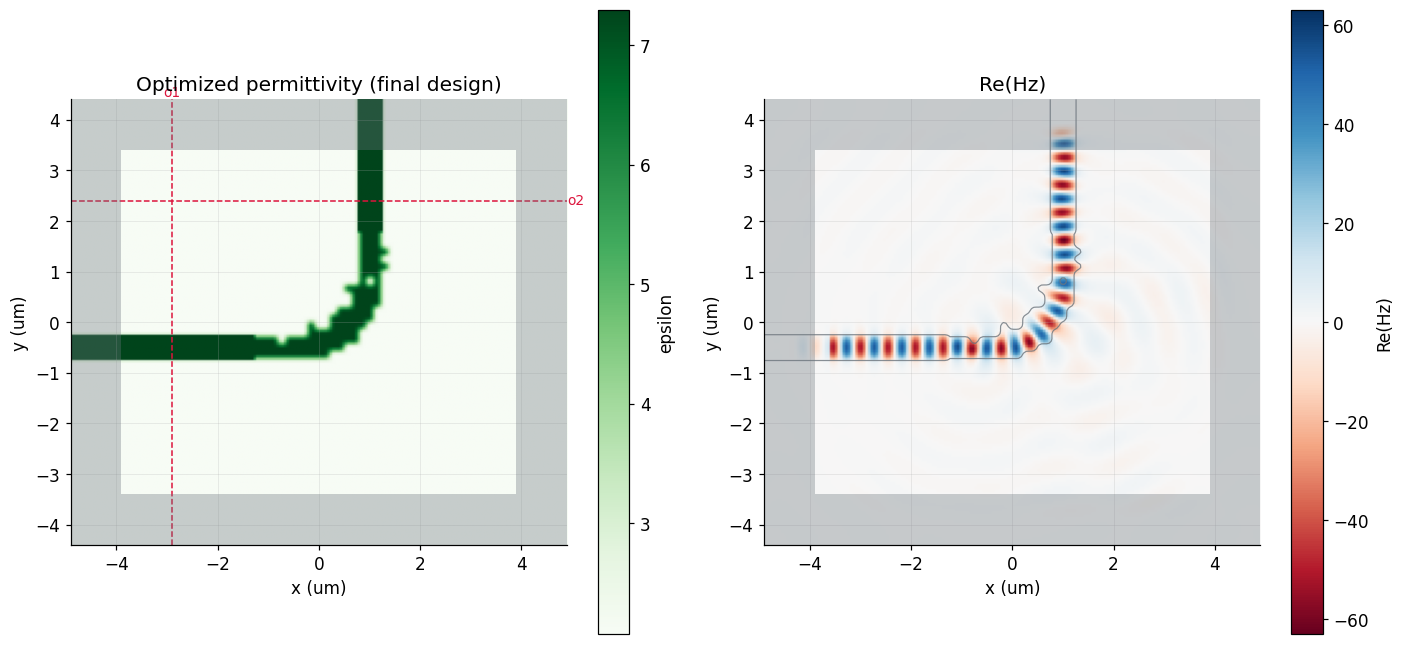

In [9]:
result = bend_topopt.simulate_baseline(params, weights=opt_result.final_weights_binarized)

fs = result.field_snapshot
print(f"dominant field: {fs.component}")

dom = bend_topopt._domain(params)
ports = [
    (dom["port1_x"], dom["y0"], "o1", "v"),
    (dom["x0"], dom["port2_y"], "o2", "h"),
]

fig, (ax_eps, ax_field) = plt.subplots(1, 2, figsize=(13, 6))
viz.plot_permittivity(result.permittivity.eps, result.permittivity.extent_um, ax=ax_eps,
                       ports=ports, pml_um=params["dpml_um"], cmap=style.CMAP_PERMITTIVITY_OPTIMIZED)
ax_eps.set_title("Optimized permittivity (final design)")
viz.plot_field(fs.field, fs.eps, fs.extent_um, component=fs.component, ax=ax_field, pml_um=params["dpml_um"])
fig.tight_layout()
plt.show()

> **STOP: Inspect the electromagnetic field before trusting the S-parameters
> below.**
>
> Check: does the field enter horizontally, turn through the optimized corner, and
> exit vertically, mostly confined to a recognizable path? Some scattering into the
> cladding is expected (this is still a lossy, imperfect design, not a fabricated
> claim of perfection) -- but if the field looks completely diffuse with no
> discernible path from input to output, the design has not actually converged to
> anything physically meaningful, regardless of what Section 6's convergence curve
> showed.

## 8. S-parameters -- the physically authoritative measurement

The complete complex 2x2 S-matrix, from the `result` computed in Section 7 -- measured
by two genuinely independent FDTD runs (excite `o1`, excite `o2`), exactly the same
method as every other component. This -- not Section 6's per-iteration `J` -- is what
Section 10 saves.

In [10]:
# The complete complex 2x2 S-matrix at band-center, from the honest,
# independently-measured result computed above -- NOT the optimizer's own
# per-iteration objective (Section 6).
for key in ["11", "12", "21", "22"]:
    s = result.s_matrix[key]
    i_mid = len(s) // 2
    print(f"S{key}: |S|^2={np.abs(s[i_mid])**2:.4f}  phase={np.angle(s[i_mid]):.3f} rad  "
          f"(at wavelength={result.wavelengths_um[i_mid]:.4f} um)")

s21p_mid = np.abs(result.s_matrix["21"][len(result.s_matrix["21"]) // 2]) ** 2
print(f"\nInsertion loss at mid-band: {-10 * np.log10(s21p_mid):.3f} dB")


S11: |S|^2=0.0145  phase=-2.841 rad  (at wavelength=1.3500 um)
S12: |S|^2=0.9211  phase=1.573 rad  (at wavelength=1.3500 um)
S21: |S|^2=0.9228  phase=1.572 rad  (at wavelength=1.3500 um)
S22: |S|^2=0.0321  phase=2.871 rad  (at wavelength=1.3500 um)

Insertion loss at mid-band: 0.349 dB


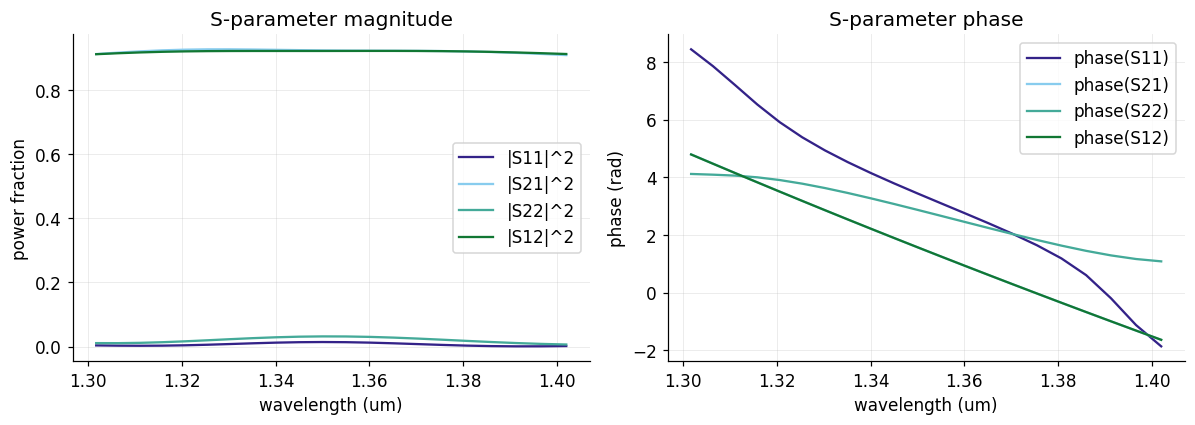

In [11]:
# Full magnitude+phase spectra for all four S-parameters, across the
# validation band -- viz.plot_sparams applies this toolkit's shared
# color/style convention.
fig = viz.plot_sparams(result.wavelengths_um, result.s_matrix, pairs=("11", "21", "22", "12"))
plt.show()


## 9. Sanity checks

Same three checks as every other component. `ENERGY_TOL`/`PASSIVITY_TOL`/
`MAX_LOSS_FRACTION` are adapted from `02_bent_waveguide.ipynb`'s bend budget -- this
is physically the same device class (a 90-degree turn with a real, expected
radiation-loss channel).

**`RECIPROCITY_TOL` is loosened further than `bend.py`'s, for a specific reason:**
the check bundles true Lorentz reciprocity (`S12=S21`, which every passive device
must satisfy) with `S11=S22`, which only holds for a device with a symmetry that
swaps its two ports. `bend.py`'s parametric quarter-circle arc happens to have that
symmetry; this module's freeform density has no such symmetry enforced anywhere in
the optimization, so `S11`/`S22` (both small) are not expected to match. What
actually matters -- `S12=S21` -- still holds to within a fraction of a percent.

In [12]:
# Same 3-check validator as bend.py (this is physically the same device
# class -- a 90-degree turn with a real radiation-loss channel), except
# RECIPROCITY_TOL is loosened for this freeform design's lack of the
# arm-swap symmetry a parametric bend has (see the markdown above).
ENERGY_TOL = 0.10
RECIPROCITY_TOL = 0.25  # loosened for THIS component's lack of arm-swap symmetry --
                         # see the explanation above. max_diff_s12_s21 (true
                         # reciprocity) is expected to stay far below this; only
                         # max_diff_s11_s22 (not a real physical requirement here)
                         # needs the slack.
PASSIVITY_TOL = 0.02
MAX_LOSS_FRACTION = 0.2  # the Euler-warm-started optimization (see Section 3/5) reaches
                          # comfortably under 10% total radiation/reflection loss -- this
                          # budget still leaves headroom without being loose enough to
                          # hide a real regression

validation = checks.run_all_checks(
    result.s_matrix,
    energy_tol=ENERGY_TOL,
    reciprocity_tol=RECIPROCITY_TOL,
    passivity_tol=PASSIVITY_TOL,
    max_loss_fraction=MAX_LOSS_FRACTION,
)

import json
print(json.dumps(validation, indent=2))
assert validation["passed"], "Optimized design failed sanity checks -- do not save or use this result."
print("\nOptimized design validated.")


{
  "energy_conservation": {
    "max_deviation_port1": 0.0,
    "max_deviation_port2": 0.0,
    "max_deviation": 0.0,
    "max_loss_fraction_allowed": 0.2,
    "tolerance": 0.1,
    "passed": true
  },
  "reciprocity": {
    "max_diff_s12_s21": 0.0030102389713549836,
    "max_diff_s11_s22": 0.16822055374538003,
    "max_diff": 0.16822055374538003,
    "tolerance": 0.25,
    "passed": true
  },
  "passivity": {
    "max_magnitude": 0.9624132855076545,
    "tolerance": 0.02,
    "passed": true
  },
  "passed": true
}

Optimized design validated.


## 10. Save artifacts

Same `.npz`/`.json` artifact pair every other component uses, via the shared
`sparams.py` -- plus two companions specific to a topology-optimized design: the final
binary density map (the actual geometry -- there is no small set of scalar geometry
parameters here) and the optimizer's convergence history.

In [13]:
# Same .npz/.json artifact pair every component uses, plus two files
# specific to a topology-optimized design: the final binary density map
# (there's no small set of scalar geometry parameters here -- the density
# grid IS the geometry) and the optimizer's convergence history.
artifact_stem = "../data/sparams/bend_topopt/baseline/bend_topopt_baseline"

metadata = {
    "component": "bend_topopt",
    "geometry_params": {
        "wg_width_um": result.sim_params["wg_width_um"],
        "design_region_x_um": result.sim_params["design_region_x_um"],
        "design_region_y_um": result.sim_params["design_region_y_um"],
        "design_grid_n": result.sim_params["design_grid_n"],
        "filter_radius_um": result.sim_params["filter_radius_um"],
        "beta_schedule": result.sim_params["beta_schedule"],
        "eta": result.sim_params["eta"],
    },
    "material_params": {
        "core_index": result.sim_params["core_index"],
        "clad_index": result.sim_params["clad_index"],
    },
    "polarization": f"TE ({result.field_snapshot.component} out-of-plane, confirmed dominant -- see Section 7)",
    "meep_resolution": result.sim_params["resolution"],
    "simulation_params": {
        k: result.sim_params[k]
        for k in ["wl_min_um", "wl_max_um", "n_freq", "dpml_um", "cell_x_um",
                  "cell_y_um", "wavelength_um", "iters_per_stage", "adjoint_minimum_run_time"]
    },
    "optimization": {
        "final_objective": float(opt_result.evaluation_history[-1]),
        "n_iterations": len(opt_result.evaluation_history),
        "fill_fraction": float(opt_result.final_weights_binarized.mean()),
    },
    "meep_version": result.sim_params["meep_version"],
    "python_version": result.sim_params["python_version"],
    "creation_date": result.sim_params["creation_date"],
    "validation": validation,
}

sparams.save_artifact(
    artifact_stem, result.wavelengths_um, result.freqs,
    result.s_matrix, result.port_names, metadata,
)
print(f"Saved artifact: {artifact_stem}.npz / .json")

density_path = "../data/sparams/bend_topopt/baseline/bend_topopt_density.npy"
np.save(density_path, opt_result.final_weights_binarized)
print(f"Saved density map: {density_path}")

convergence_path = "../data/sparams/bend_topopt/baseline/bend_topopt_convergence.npz"
np.savez(convergence_path, evaluation_history=opt_result.evaluation_history)
print(f"Saved convergence history: {convergence_path}")


Saved artifact: ../data/sparams/bend_topopt/baseline/bend_topopt_baseline.npz / .json
Saved density map: ../data/sparams/bend_topopt/baseline/bend_topopt_density.npy
Saved convergence history: ../data/sparams/bend_topopt/baseline/bend_topopt_convergence.npz


## 11. Design point

Same single-source-of-truth role as every other component's design point. Provenance
method is `"adjoint_topology_optimization"` rather than `"baseline_only"` or
`"sweep_selection"` -- there is one optimized design, selected by the optimizer itself
rather than by a human comparing sweep points, but still only trusted because Section 9
validated it, exactly like every other component.

In [14]:
# Single source-of-truth design point, same role as every other component's --
# provenance is "adjoint_topology_optimization" rather than "baseline_only" or
# "sweep_selection" since there's one optimized design, not a human-compared
# sweep, but it's still only trusted because Section 9 validated it.
design_point_path = "../data/design_points/bend_topopt.yaml"

design_points.save_design_point(design_point_path, {
    "component": "bend_topopt",
    "parameters": {**metadata["geometry_params"], **metadata["material_params"]},
    "source_artifact": "data/sparams/bend_topopt/baseline/bend_topopt_baseline",
    "density_map": "data/sparams/bend_topopt/baseline/bend_topopt_density.npy",
    "provenance": {
        "method": "adjoint_topology_optimization",
        "date": metadata["creation_date"],
        "meep_version": metadata["meep_version"],
    },
    "validation": validation,
    "rationale": (
        f"Adjoint-optimized over {len(opt_result.evaluation_history)} NLopt MMA "
        f"iterations, warm-started from a rasterized R={params['init_bend_radius_um']}um "
        f"Euler (clothoid) bend (build_euler_initial_density()) rather than a uniform "
        f"gray density -- a blank start did not converge to a design that passed "
        f"checks.run_all_checks under this module's corrected TE constraint (see the "
        f"module docstring's TE/TM correction), while refining from this warm start "
        f"did. Final design binarized at a 0.5 density threshold and validated by an "
        f"independent two-port FDTD measurement (not the optimizer's own objective). "
        f"Edit this rationale directly, or re-run Section 5 with more iterations / a "
        f"different filter radius, if a stronger design is found."
    ),
})
print(f"Saved design point: {design_point_path}")


Saved design point: ../data/design_points/bend_topopt.yaml


## 12. Bend-topopt SAX model

`src/pic_toolkit/models/bend_topopt.py` is the reusable LEGO brick built from the
design point saved above. **Not exercised in this notebook** -- this notebook already
imports meep, and the whole point of the SAX model is that it must work in a process
that never has -- so it should be verified separately, in a clean, meep-free process
(same approach every other component's model uses).

In [15]:
# Print the reusable SAX model this design point feeds -- verified separately
# in a clean, meep-free process (see Section 12 markdown).
with open("../src/pic_toolkit/models/bend_topopt.py") as f:
    print(f.read())


"""SAX-compatible component model for the adjoint-topology-optimized bend.

Architectural rule: this file NEVER imports meep, and NEVER launches an FDTD
simulation. It only reads the cached, validated S-parameter artifact that the
`04_bend_topology_optimization.ipynb` notebook already produced (from the
honest, plain forward two-port `simulate_baseline()` validation, not from the
optimizer's own per-iteration objective), via the design point that names it.

Same shape as the since-removed models/ring.py -- see that file for the general pattern this
mirrors.
"""

from __future__ import annotations

import sys
from pathlib import Path

import numpy as np

from .. import design_points, sparams

assert "meep" not in sys.modules, "pic_toolkit.models.bend_topopt must never coexist with a meep import"

_REPO_ROOT = Path(__file__).resolve().parents[3]
_DESIGN_POINT_PATH = _REPO_ROOT / "data" / "design_points" / "bend_topopt.yaml"


def _resolve_artifact_stem(design_point: dict) -> Path:
    so

---

## 13. Summary

An adjoint-optimized 90-degree bend design was produced, honestly re-measured with the
toolkit's standard two-port method (not the optimizer's own per-iteration objective),
validated, and cached. The SAX model can now be loaded in any meep-free process via
`from pic_toolkit.models.bend_topopt import bend_topopt`, exactly like every other
component -- and compared directly against `bend.py`'s parametric-arc design at the
same footprint.